## BDGDM fit test

In [1]:
from cmdstanpy import CmdStanModel
from bdgdm import load_example_data, fit_one_gene_bdgdm, BDGDMConfig
from bdgdm.preprocessing import prepare_gene_data
from bdgdm.plot import plot_copy_number_fit, plot_ppc_mean, plot_ppc_variance

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from typing import Any, Sequence

import arviz as az
import xarray as xr

In [4]:
# Compile Stan models
model_single = CmdStanModel(stan_file="../bdgdm/stan/bdgdm_single.stan")

model_subtype = CmdStanModel(stan_file="../bdgdm/stan/bdgdm_subtype.stan")

In [7]:
# Load example data
gene_df = load_example_data()
gene_df.head()

,gene,sampleID,expr,copies,subtype,purity,ploidy,sf
0,ACVR1B,CRC.SW.U0001.T,7593,2,MSS,0.41,3.8,1.293201
1,ACVR1B,CRC.SW.U0002.T,5003,2,MSS,0.37,3.3,1.024008
2,ACVR1B,CRC.SW.U0004.T,4994,2,MSS,0.58,3.2,1.169870
3,ACVR1B,CRC.SW.U0030.T,6231,2,MSS,0.59,2.2,1.290047
4,ACVR1B,CRC.SW.U0066.T,2908,2,MSS,0.41,1.9,0.971163


In [9]:
# Configure inference
config = BDGDMConfig(
    engine="nuts",
    chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.90,
    seed=123,
    return_ppc=False,
    save_draws=False,
    save_summary=False
)

#### Fit one gene 

In [11]:
fit = fit_one_gene_bdgdm(
    gene_df,
    gene="BRAF",
    model_single=model_single,
    model_subtype=model_subtype,
    config=config
)

21:57:56 - cmdstanpy - INFO - CmdStan start processing
21:57:56 - cmdstanpy - INFO - Chain [1] start processing
21:57:56 - cmdstanpy - INFO - Chain [2] start processing
21:57:56 - cmdstanpy - INFO - Chain [3] start processing
21:57:56 - cmdstanpy - INFO - Chain [4] start processing
21:59:20 - cmdstanpy - INFO - Chain [1] done processing
21:59:21 - cmdstanpy - INFO - Chain [3] done processing
21:59:22 - cmdstanpy - INFO - Chain [2] done processing
21:59:23 - cmdstanpy - INFO - Chain [4] done processing


In [13]:
fit.posterior

{'analysis_mode': 'subtype_comparison',
 'subtype_levels': ['MSI', 'MSS'],
 'n_subtypes': 2,
 'engine': 'nuts',
 'phi_median': 32.8266,
 'phi_q025': 30.023982500000002,
 'phi_q975': 35.946395,
 'b_noncancer_log_median': 7.74615,
 'b_noncancer_log_q025': 7.71306825,
 'b_noncancer_log_q975': 7.7785614999999995,
 'tumor0_lfc_median': 0.4993968232264396,
 'tumor0_lfc_q025': 0.40190591235609535,
 'tumor0_lfc_q975': 0.6004850941812404,
 'ppd_tumor': 1.0,
 'p_rope_tumor': 0.0,
 'p_pos_tumor': 1.0,
 'p_neg_tumor': 0.0,
 'delta_scaling_median': -0.28372600000000003,
 'delta_scaling_q025': -0.814570625,
 'delta_scaling_q975': 0.2640601250000005,
 'ppd_scaling': 0.845,
 'p_pos_scaling': 0.155,
 'p_neg_scaling': 0.845,
 'delta_dev_median': -0.1187225,
 'delta_dev_q025': -0.535669,
 'delta_dev_q975': 0.3007891500000001,
 'ppd_dev': 0.70325,
 'p_pos_dev': 0.29675,
 'p_neg_dev': 0.70325,
 'subtype_label_s1': 'MSI',
 'b0_s1_median': 7.322805,
 'b0_s1_q025': 7.2474585000000005,
 'b0_s1_q975': 7.3933467

In [15]:
fit.diagnostics

{'engine': 'nuts',
 'analysis_mode': 'subtype_comparison',
 'warnings': [],
 'summary_columns': ['Mean',
  'MCSE',
  'StdDev',
  '5%',
  '50%',
  '95%',
  'N_Eff',
  'N_Eff/s',
  'R_hat'],
 'rhat_column': 'R_hat',
 'bulk_ess_column': 'N_Eff',
 'tail_ess_column': None,
 'max_rhat': 1.00373,
 'min_rhat': 0.999101,
 'min_bulk_ess': 1678.37,
 'min_tail_ess': nan,
 'n_chains': 4,
 'n_draws_per_chain': 1000,
 'n_draws_total': 4000,
 'n_divergent': 0,
 'max_treedepth_observed': 7,
 'diagnose': 'Processing csv files: /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmpndbxqp1b/bdgdm_subtypemvevpnv9/bdgdm_subtype-20260713215756_1.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmpndbxqp1b/bdgdm_subtypemvevpnv9/bdgdm_subtype-20260713215756_2.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmpndbxqp1b/bdgdm_subtypemvevpnv9/bdgdm_subtype-20260713215756_3.csv, /var/folders/mh/vvy722dj18x7xj41n2qbdzs80000gn/T/tmpndbxqp1b/bdgdm_subtypemvevpnv9/bdgdm_subtype-20260713215756_4.csv\n\nCheckin

Available posterior variables: ['b0_mean', 'b0_offset', 'b_scaling_mean', 'b_scaling_offset', 'b_dev_mean', 'b_dev_offset', 'b_noncancer_log', 'phi', 'b0', 'b_scaling', 'b_deviation', 'log_mu', 'b0_off', 'scale_off', 'dev_off', 'delta_tumor0_log', 'tumor0_fc', 'delta_scaling', 'delta_dev', 'tumor_fc_2to1', 'fracCN_2to1', 'tumor_fc_2to3', 'fracCN_2to3', 'tumor_fc_2to4', 'fracCN_2to4', 'lp_2to1', 'lp_2to3', 'lp_2to4', 'lp_scaling_2to1', 'lp_dev_2to1', 'lp_scaling_2to3', 'lp_dev_2to3', 'lp_scaling_2to4', 'lp_dev_2to4', 'cancel_index_2to1', 'cancel_index_2to3', 'cancel_index_2to4', 'y_rep', 'mu_rep']


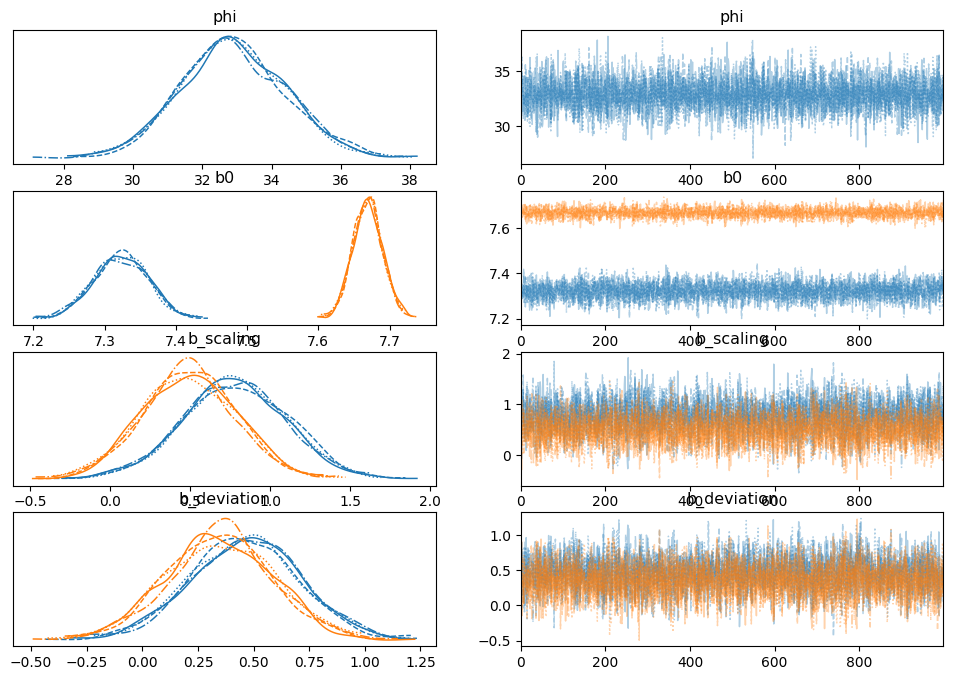

In [19]:
# Plot trace diagnostic

idata = az.from_cmdstanpy(posterior=fit.fit)

available = list(idata.posterior.data_vars)
print("Available posterior variables:", available)

az.plot_trace(
    idata,
    var_names=[
        "phi",
        "b0",
        "b_scaling",
        "b_deviation",
    ],
)

plt.show()

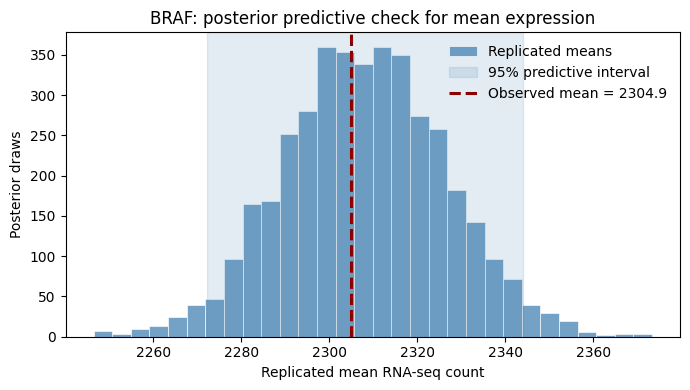

In [203]:
# Posterior predictive check - Mean

fig, ax, ppc_summary = plot_ppc_mean(
    fit,
    stan_data["y"],
    gene="BRAF",
    histogram_color="steelblue",
    observed_color="darkred",
    credible_interval=0.95,
)

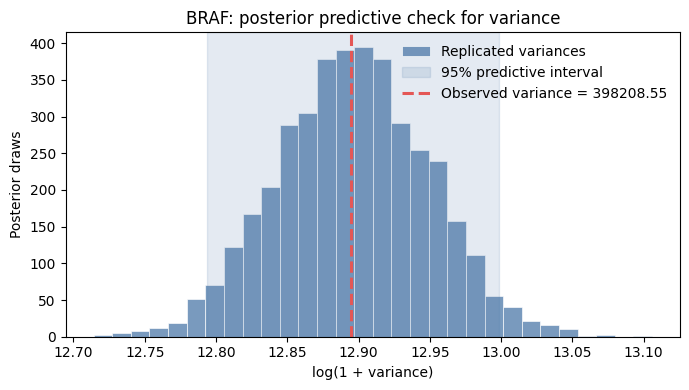

In [205]:
# Posterior predictive check - Variance

fig, ax, variance_summary = plot_ppc_variance(
    fit,
    stan_data["y"],
    gene="BRAF",
    histogram_color="#4C78A8",
    observed_color="#E45756",
    credible_interval=0.95,
)

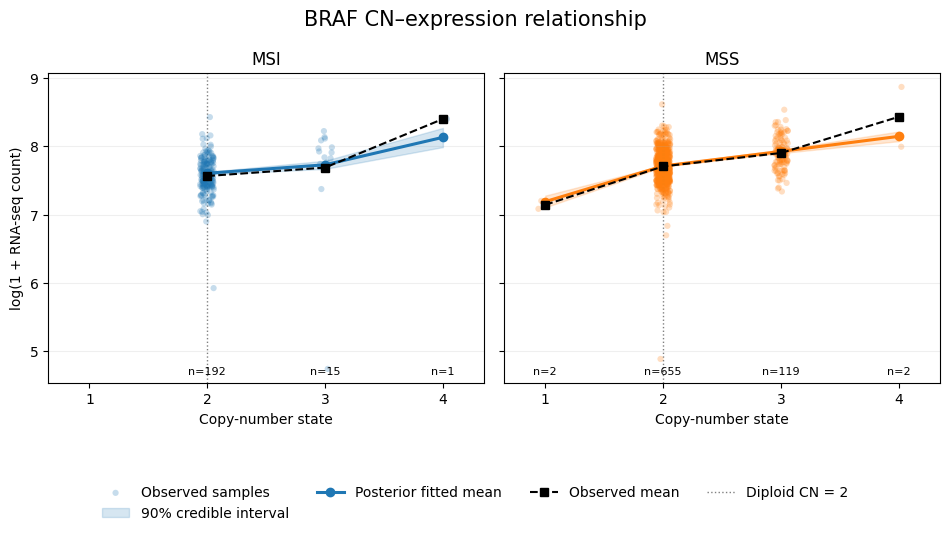

In [207]:
# Copy-number-expression relationship

processed_df, stan_data, metadata = prepare_gene_data(
    gene_df=gene_df,
    gene="BRAF",
    subtype_col="subtype",
)

fig, cn_summary = plot_copy_number_fit(
    fit,
    processed_df,
    subtype_col="subtype",
    cn_col="copies",
    expr_col="expr",
    credible_interval=0.90,
)

#### Fit multiple genes

In [37]:
rep_genes = ["ASXL1", "SMAD4", "BCOR", "KRAS"]

fits_rep = {}
fit_errors = {}

for gene in rep_genes:
    print(f"Fitting {gene}...")

    try:
        result = fit_one_gene_bdgdm(
            gene_df=gene_df,
            gene=gene,
            model_single=model_single,
            model_subtype=model_subtype,
            config=config,
        )

        fits_rep[gene] = result

        print(
            f"Completed {gene}: "
            f"mode={result.analysis_mode}, "
            f"converged={result.diagnostics.get('converged')}"
        )

    except Exception as error:
        fit_errors[gene] = error

        print(
            f"Failed {gene}: "
            f"{type(error).__name__}: {error}"
        )

22:36:42 - cmdstanpy - INFO - CmdStan start processing
22:36:42 - cmdstanpy - INFO - Chain [1] start processing
22:36:42 - cmdstanpy - INFO - Chain [2] start processing
22:36:42 - cmdstanpy - INFO - Chain [3] start processing
22:36:42 - cmdstanpy - INFO - Chain [4] start processing


Fitting ASXL1...


22:37:53 - cmdstanpy - INFO - Chain [1] done processing
22:37:58 - cmdstanpy - INFO - Chain [4] done processing
22:38:00 - cmdstanpy - INFO - Chain [2] done processing
22:38:02 - cmdstanpy - INFO - Chain [3] done processing
22:38:25 - cmdstanpy - INFO - CmdStan start processing
22:38:25 - cmdstanpy - INFO - Chain [1] start processing
22:38:25 - cmdstanpy - INFO - Chain [2] start processing
22:38:25 - cmdstanpy - INFO - Chain [3] start processing
22:38:25 - cmdstanpy - INFO - Chain [4] start processing


Completed ASXL1: mode=subtype_comparison, converged=True
Fitting SMAD4...


22:39:21 - cmdstanpy - INFO - Chain [3] done processing
22:39:23 - cmdstanpy - INFO - Chain [2] done processing
22:39:25 - cmdstanpy - INFO - Chain [1] done processing
22:39:28 - cmdstanpy - INFO - Chain [4] done processing
22:39:50 - cmdstanpy - INFO - CmdStan start processing
22:39:50 - cmdstanpy - INFO - Chain [1] start processing
22:39:50 - cmdstanpy - INFO - Chain [2] start processing
22:39:50 - cmdstanpy - INFO - Chain [3] start processing
22:39:50 - cmdstanpy - INFO - Chain [4] start processing


Completed SMAD4: mode=subtype_comparison, converged=True
Fitting BCOR...


22:40:47 - cmdstanpy - INFO - Chain [3] done processing
22:40:48 - cmdstanpy - INFO - Chain [1] done processing
22:40:49 - cmdstanpy - INFO - Chain [4] done processing
22:40:53 - cmdstanpy - INFO - Chain [2] done processing
22:41:15 - cmdstanpy - INFO - CmdStan start processing
22:41:15 - cmdstanpy - INFO - Chain [1] start processing
22:41:15 - cmdstanpy - INFO - Chain [2] start processing
22:41:15 - cmdstanpy - INFO - Chain [3] start processing
22:41:15 - cmdstanpy - INFO - Chain [4] start processing


Completed BCOR: mode=subtype_comparison, converged=True
Fitting KRAS...


22:42:08 - cmdstanpy - INFO - Chain [2] done processing
22:42:16 - cmdstanpy - INFO - Chain [3] done processing
22:42:17 - cmdstanpy - INFO - Chain [1] done processing
22:43:33 - cmdstanpy - INFO - Chain [4] done processing


Completed KRAS: mode=subtype_comparison, converged=True


In [53]:
posterior_table = pd.DataFrame([{
    "gene": gene,
    **result.posterior,
}
    for gene, result in fits_rep.items()
    ]
)

posterior_table

,gene,analysis_mode,subtype_levels,n_subtypes,engine,phi_median,phi_q025,phi_q975,b_noncancer_log_median,b_noncancer_log_q025,...,lp_dev_2to4_s2_q975,cancel_index_2to1_s2_median,cancel_index_2to1_s2_q025,cancel_index_2to1_s2_q975,cancel_index_2to3_s2_median,cancel_index_2to3_s2_q025,cancel_index_2to3_s2_q975,cancel_index_2to4_s2_median,cancel_index_2to4_s2_q025,cancel_index_2to4_s2_q975
0,ASXL1,subtype_comparison,"[MSI, MSS]",2,nuts,22.75645,20.792568,24.866332,8.26963,8.227597,...,-0.001763,0.094477,0.000852,0.157101,-0.161509,-0.268566,-0.001456,-0.188953,-0.314201,-0.001704
1,SMAD4,subtype_comparison,"[MSI, MSS]",2,nuts,12.54670,11.455445,13.684535,7.42931,7.360983,...,2.075986,-8.099210,-170.668875,-2.913323,13.845700,4.980360,291.760300,16.198400,5.826646,341.337725
2,BCOR,subtype_comparison,"[MSI, MSS]",2,nuts,14.97010,13.717340,16.255550,7.80224,7.744538,...,0.387311,-0.554191,-6.388970,1.191134,0.947397,-2.036252,10.922015,1.108380,-2.382269,12.777940
3,KRAS,subtype_comparison,"[MSI, MSS]",2,nuts,18.02985,16.521275,19.605907,7.67916,7.631941,...,0.688156,-0.417789,-1.207981,-0.143745,0.714214,0.245734,2.065052,0.835577,0.287490,2.415962


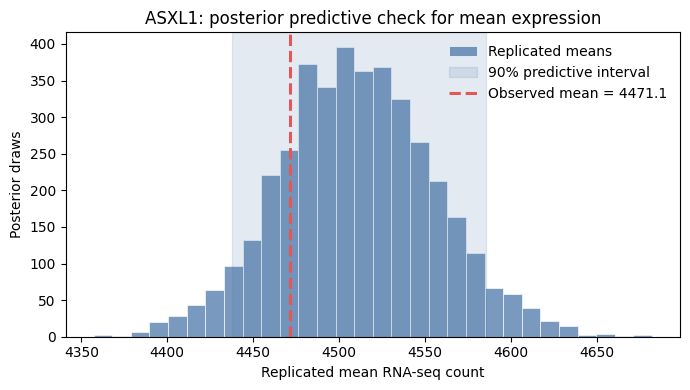

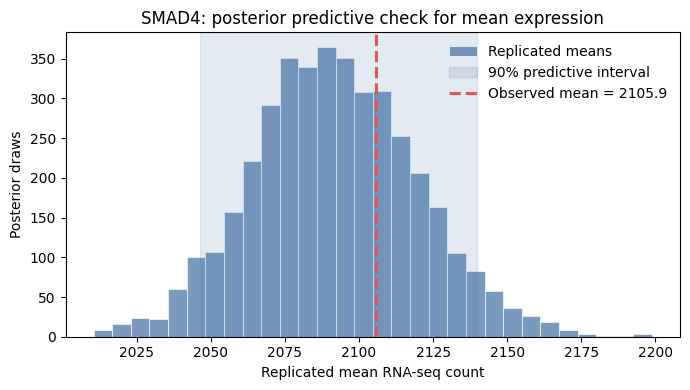

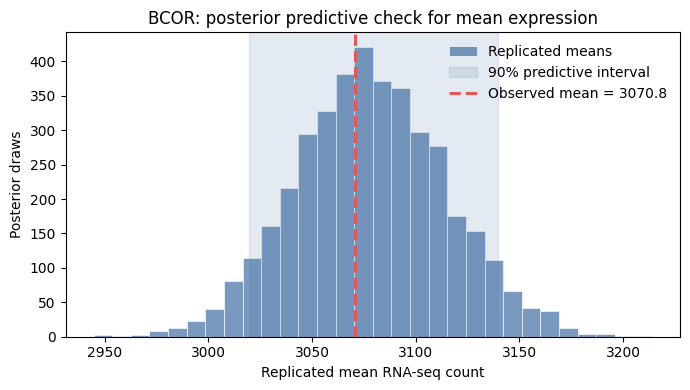

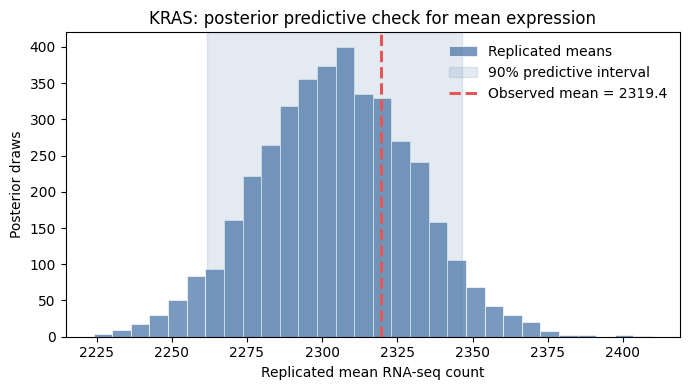

In [21]:
# Plot PPC mean for every successful gene

for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, ax, ppc_summary = plot_ppc_mean(
        result,
        stan_data["y"],
        gene=gene,
        histogram_color="#4C78A8",
        observed_color="#E45756",
        show=True,
    )

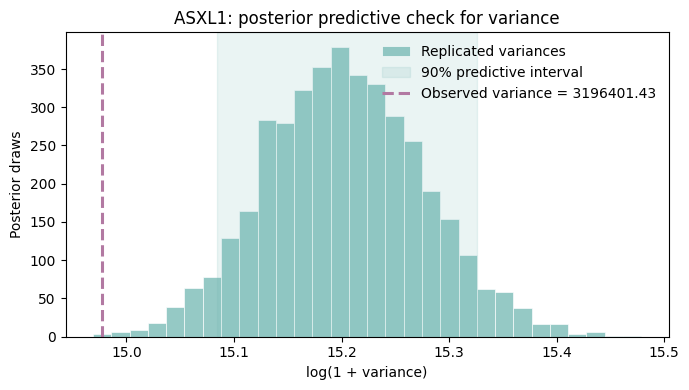

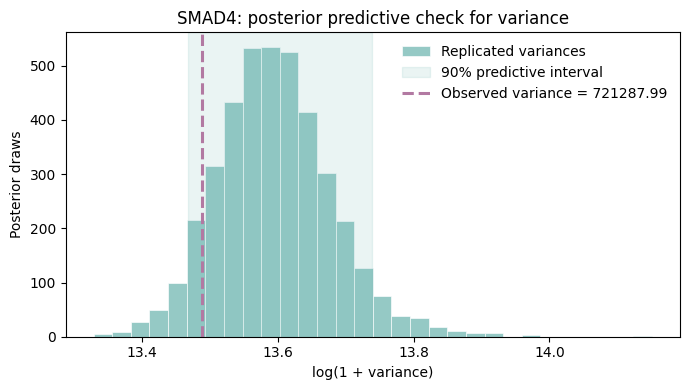

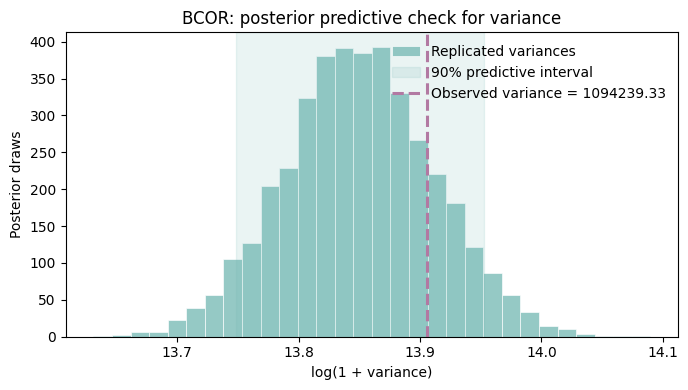

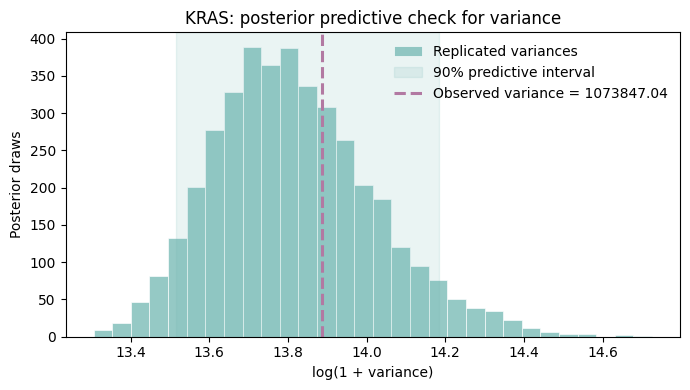

In [23]:
# Plot PPC variance for every successful gene
for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, ax, variance_summary = plot_ppc_variance(
        result,
        stan_data["y"],
        gene=gene,
        histogram_color="#72B7B2",
        observed_color="#B279A2",
        show=True,
    )

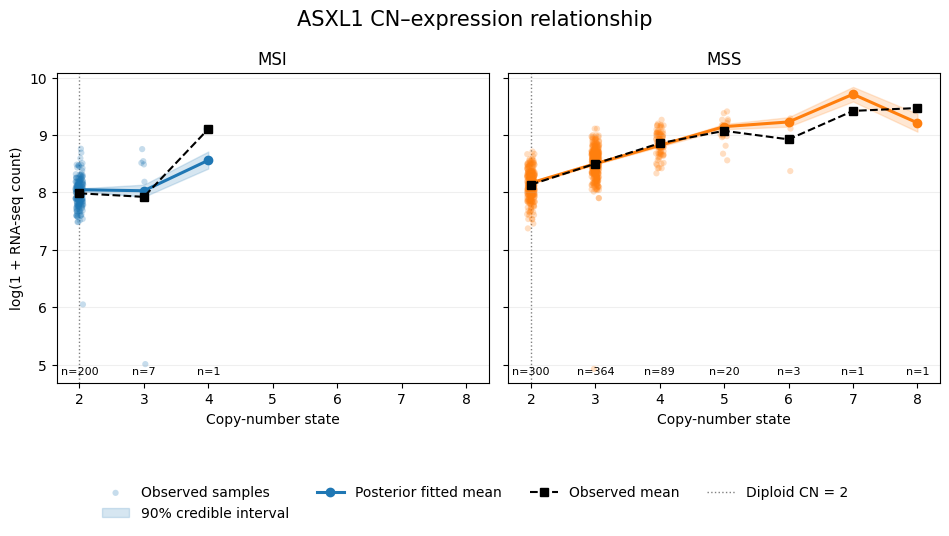

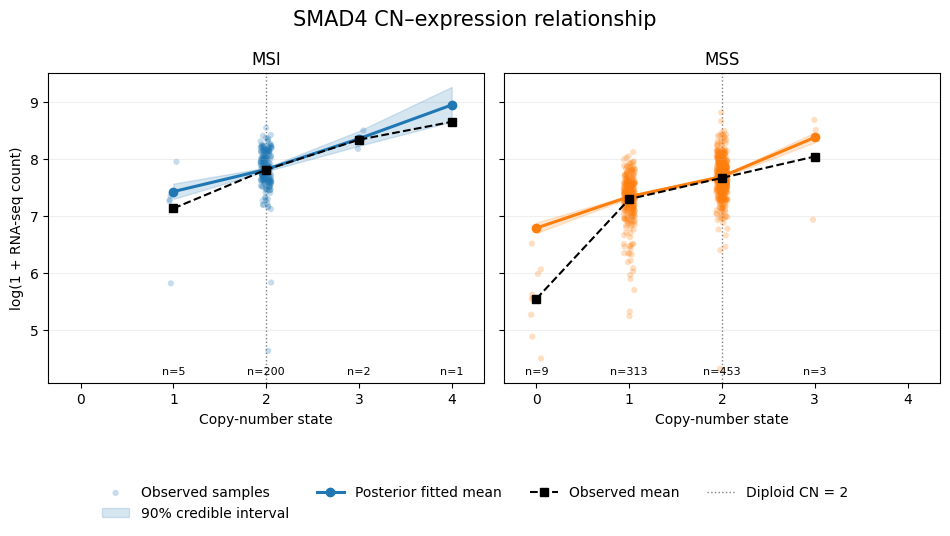

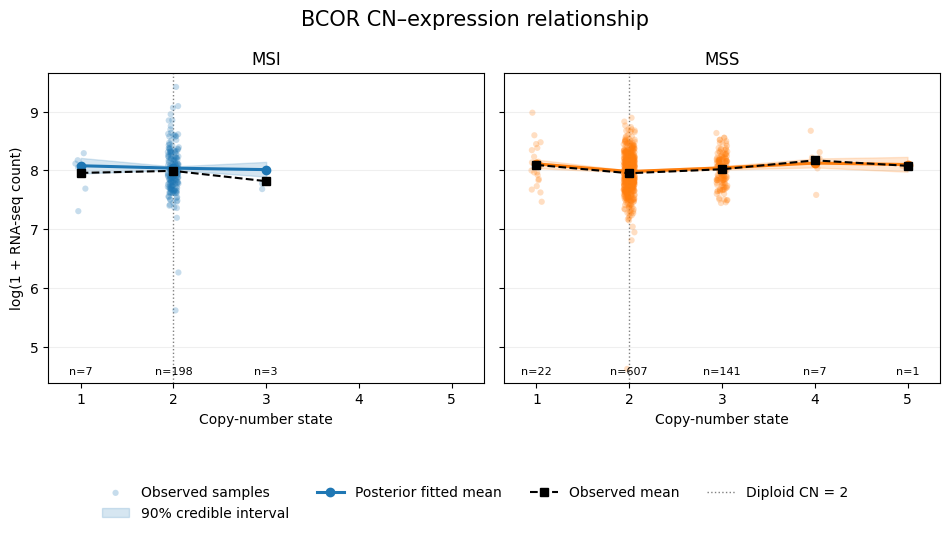

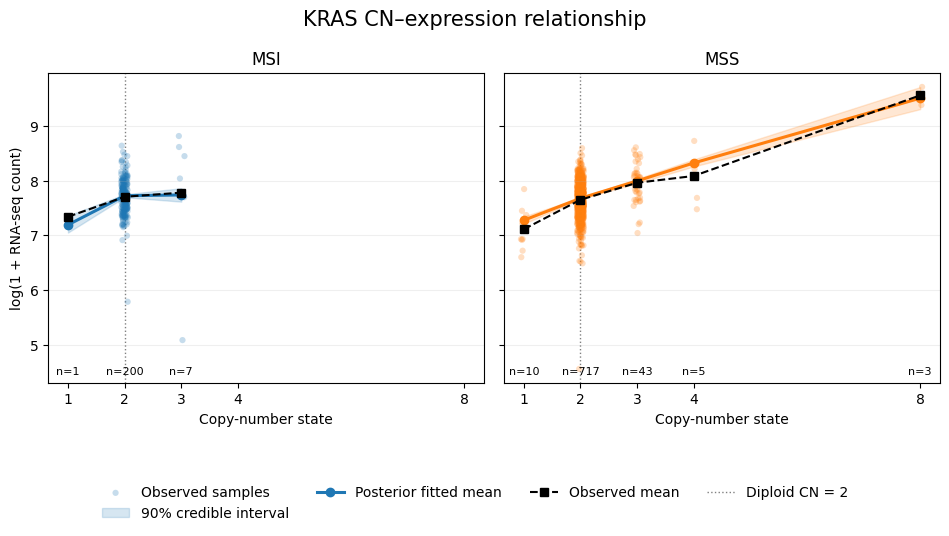

In [25]:
# Plot CN-expression relationship fit

for gene, result in fits_rep.items():
    processed_df, stan_data, metadata = prepare_gene_data(
        gene_df=gene_df,
        gene=gene,
        subtype_col="subtype",
    )

    fig, cn_summary = plot_copy_number_fit(
        result,
        processed_df,
        credible_interval=0.90,
    )

    plt.show()

### Gene-dosage classification

In [41]:
from bdgdm.classify import ClassificationThresholds, classify_fits

In [47]:
thresholds = ClassificationThresholds(
    ppd_sig=0.95,
    rope_low=0.05,
    rope_high=0.95,
    dose_prob_sensitive=0.95,
    dose_prob_insensitive=0.95,
    cancel_threshold=0.20,
    overcomp_threshold=1.00,
    hyper_threshold=0.50,
    low_cn_aneup_threshold=10,
)

In [49]:
# Single gene

classif = classify_fit(fit,
                      thresholds=thresholds)
classif

{'gene': 'BRAF',
 'status': 'ok',
 'fit_flag': 'ok',
 'analysis_mode': 'subtype_comparison',
 'N': 986,
 'n_aneup': 139,
 'cna': 'all',
 'S': 2,
 'subtype_levels': ['MSI', 'MSS'],
 'subtype_levels_str': 'MSI|MSS',
 'de_status': 'DE',
 'ppd_tumor': 1.0,
 'p_rope_tumor': 0.0,
 'tumor0_lfc_median': 0.4993968232264396,
 'tumor0_lfc_q025': 0.40190591235609535,
 'tumor0_lfc_q975': 0.6004850941812404,
 'rewiring_status': 'rewiring_uncertain',
 'scaling_rewired': False,
 'deviation_rewired': False,
 'scaling_rewiring_evidence': 'ppd_only',
 'deviation_rewiring_evidence': 'ppd_only',
 'ppd_scaling': 0.845,
 'ppd_dev': 0.70325,
 'p_rope_scaling': nan,
 'p_rope_dev': nan,
 'delta_scaling_median': -0.28372600000000003,
 'delta_scaling_q025': -0.814570625,
 'delta_scaling_q975': 0.2640601250000005,
 'delta_dev_median': -0.1187225,
 'delta_dev_q025': -0.535669,
 'delta_dev_q975': 0.3007891500000001,
 'subtype_s1': 'MSI',
 'response_class_s1': 'HYPER',
 'response_reason_s1': 'supported_hyper_pattern'

In [61]:
# Multiple genes

classified_rep = classify_fits(fits_rep,
                             thresholds=thresholds)
classified_rep

,gene,status,fit_flag,analysis_mode,N,n_aneup,cna,S,subtype_levels,subtype_levels_str,...,fracCN_2to4_median_s2,direction_probability_2to4_s2,rope_probability_2to4_s2,response_class_MSS,response_reason_MSS,response_subclass_MSS,transition_2to1_MSS,transition_2to3_MSS,transition_2to4_MSS,summary_label
0,ASXL1,ok,ok,subtype_comparison,986,486,all,2,"[MSI, MSS]",MSI|MSS,...,1.871128,1.000,0.00000,DSG,supported_dsg_pattern,None,proportional,proportional,proportional,"DE | rewiring_uncertain | MSI:DSG,MSS:DSG"
1,SMAD4,ok,ok,subtype_comparison,986,333,all,2,"[MSI, MSS]",MSI|MSS,...,3.712295,1.000,0.00000,HYPER,supported_hyper_pattern,None,hyperactive,hyperactive,hyperactive,"DE-uncertain | rewired:deviation | MSI:HYPER,M..."
2,BCOR,ok,ok,subtype_comparison,986,181,all,2,"[MSI, MSS]",MSI|MSS,...,0.049385,0.244,0.74575,DIG,all_transition_effects_small,median_based,weak,null,weak,"DE-null | rewiring_uncertain | MSI:DIG,MSS:DIG"
3,KRAS,ok,ok,subtype_comparison,986,69,all,2,"[MSI, MSS]",MSI|MSS,...,1.742322,1.000,0.00000,HYPER,supported_hyper_pattern,None,weak,hyperactive,hyperactive,"DE-null | rewiring_uncertain | MSI:HYPER,MSS:H..."
